In [1]:
import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import pyodbc
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings("ignore")

In [2]:
# connecting to the SSMS SQL Server 

server = 'DESKTOP-RNHKNLA\SQLEXPRESS'
database = 'loan_risk_analysis'

connection_string = (
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

engine = create_engine(connection_string)

# Reading the tables in the Databases

df=pd.read_sql("SELECT  * FROM Loan_analysis_data_PYH ", engine)

## Basic Data Checks

In [87]:
## No of Rows and columns in the data

df.shape

(51336, 79)

In [86]:
## DataFrame Columns

df.columns

Index(['time_since_recent_payment', 'num_times_delinquent',
       'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts',
       'num_deliq_6_12mts', 'max_deliq_6mts', 'max_deliq_12mts',
       'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std', 'num_std_6mts',
       'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_dbt', 'num_dbt_6mts',
       'num_dbt_12mts', 'num_lss', 'num_lss_6mts', 'num_lss_12mts',
       'recent_level_of_deliq', 'tot_enq', 'cc_enq', 'cc_enq_l6m',
       'cc_enq_l12m', 'pl_enq', 'pl_enq_l6m', 'pl_enq_l12m',
       'time_since_recent_enq', 'enq_l12m', 'enq_l6m', 'enq_l3m',
       'maritalstatus', 'education', 'age', 'gender', 'netmonthlyincome',
       'time_with_curr_empr', 'pct_of_active_tls_ever',
       'pct_opened_tls_l6m_of_l12m', 'pct_currentbal_all_tl', 'cc_flag',
       'pl_flag', 'pct_pl_enq_l6m_of_l12m', 'pct_cc_enq_l6m_of_l12m',
       'pct_pl_enq_l6m_of_ever', 'pct_cc_enq_l6m_of_ever', 'hl_flag',
       'gl_flag', 'last_prod_enq2', 'first_

In [5]:
## making the column names into lowercase

df.columns=df.columns.str.lower()

In [6]:
## Distribution of Aprroval flag

df.approved_flag.value_counts(normalize=True)*100

approved_flag
2    62.722066
3    14.516129
4    11.457846
1    11.303958
Name: proportion, dtype: float64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 80 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   prospectid                  51336 non-null  int64  
 1   time_since_recent_payment   51336 non-null  int64  
 2   num_times_delinquent        51336 non-null  int64  
 3   max_recent_level_of_deliq   51336 non-null  int64  
 4   num_deliq_6mts              51336 non-null  int64  
 5   num_deliq_12mts             51336 non-null  int64  
 6   num_deliq_6_12mts           51336 non-null  int64  
 7   max_deliq_6mts              51336 non-null  int64  
 8   max_deliq_12mts             51336 non-null  int64  
 9   num_times_30p_dpd           51336 non-null  int64  
 10  num_times_60p_dpd           51336 non-null  int64  
 11  num_std                     51336 non-null  int64  
 12  num_std_6mts                51336 non-null  int64  
 13  num_std_12mts               513

In [88]:
## checking key Metrix for numerical columns

df.select_dtypes(exclude='object').describe()

,time_since_recent_payment,num_times_delinquent,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,...,cc_tl,consumer_tl,gold_tl,home_tl,pl_tl,secured_tl,unsecured_tl,other_tl,age_oldest_tl,age_newest_tl
count,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,...,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000
mean,234.797199,1.573749,13.521953,0.184977,0.480053,0.295076,3.625565,7.263908,0.728884,0.426971,...,0.124981,1.136084,1.561847,0.070146,0.282511,2.844904,2.013694,1.089762,45.367325,15.773960
std,450.426580,4.165012,53.336976,0.710240,1.522210,1.027471,24.863442,35.253980,2.762120,2.101404,...,0.505201,2.227997,5.376434,0.340861,0.858168,6.187177,3.198322,2.417496,41.722317,21.988177
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,54.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,4.000000
50%,74.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,33.000000,8.000000
75%,161.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,3.000000,2.000000,1.000000,64.000000,17.000000
max,6065.000000,74.000000,900.000000,12.000000,28.000000,20.000000,900.000000,900.000000,60.000000,52.000000,...,27.000000,41.000000,235.000000,10.000000,29.000000,235.000000,55.000000,80.000000,392.000000,392.000000


In [9]:
## checking for missing values

df.isna().sum().sum()

np.int64(0)

In [10]:
## checking for duplicates 

df.duplicated(subset='prospectid').sum()

np.int64(0)

In [11]:
##checking for incorrect data types

pd.DataFrame(df.dtypes).head(10)

,0
prospectid,int64
time_since_recent_payment,int64
num_times_delinquent,int64
max_recent_level_of_deliq,int64
num_deliq_6mts,int64
num_deliq_12mts,int64
num_deliq_6_12mts,int64
max_deliq_6mts,int64
max_deliq_12mts,int64
num_times_30p_dpd,int64


In [12]:
## converting the bool dtypes to int

df['cc_flag']=df['cc_flag'].astype('int')
df['pl_flag']=df['pl_flag'].astype('int')
df['hl_flag']=df['hl_flag'].astype('int')
df['gl_flag']=df['gl_flag'].astype('int')

In [13]:
# Converting the Approved_Flag to binary class (p1,p2 = 0 , p3,p4 =1)

df['approved_flag'] = pd.Series(np.where((df['approved_flag'] == 1) | (df['approved_flag'] == 2),0,1 ))

# Descriptive and Diagnostic Analysis

In [14]:
## Analysis Will be done on df1
## Modelling will be done on df

df1=df.copy()

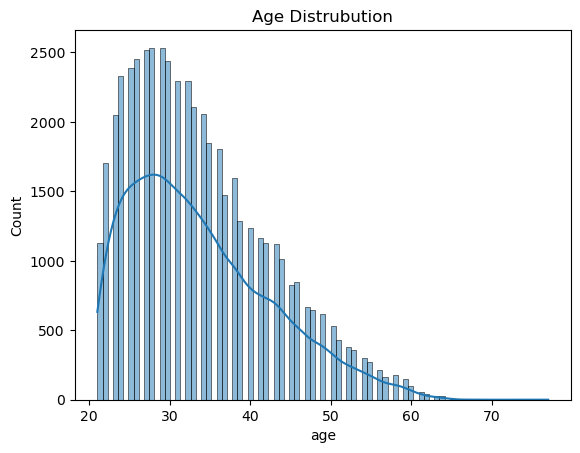

Avg AGE: 33.758532024310426


In [15]:
#Distrubution of the Age 

sns.histplot(df1.age,kde=True)
plt.title('Age Distrubution')
plt.show()
print('Avg AGE:',df1.age.mean())

In [16]:
### approved_flag Distrubutition

df1.approved_flag.value_counts(normalize=True)*100

approved_flag
0    74.026025
1    25.973975
Name: proportion, dtype: float64

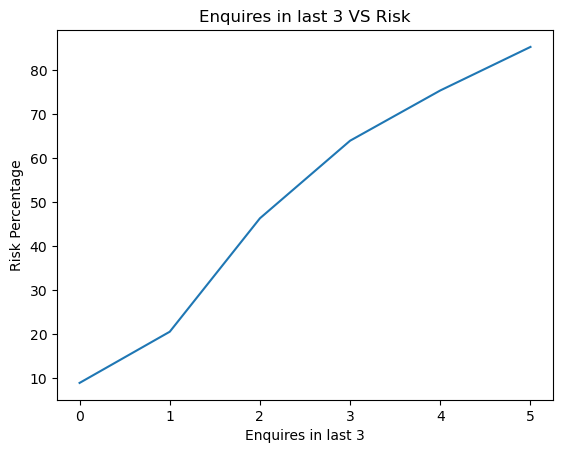

In [17]:
## When the no of enquery increase 4 in last 3 months risk percentage 85+

marginal = df1.groupby('enq_l3m')['approved_flag'].mean()
marginal=marginal.head(6)*100

## plotting into a bar plot
marginal.plot(kind='line')

plt.title("Enquires in last 3 VS Risk")
plt.xlabel("Enquires in last 3")
plt.ylabel("Risk Percentage")
plt.show()


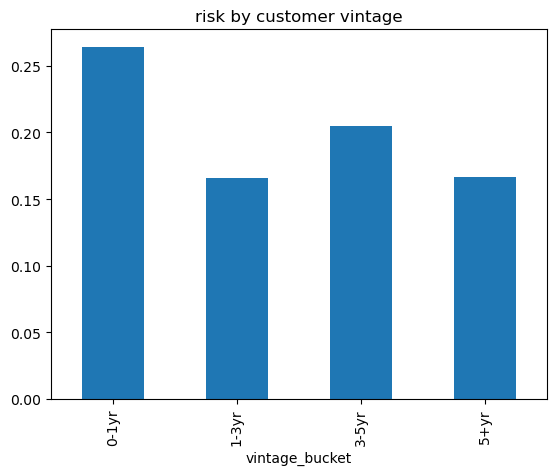

In [18]:
## creating groups in time_with_curr_empr

df1['vintage_bucket'] = pd.cut(
    df1['time_with_curr_empr'],
    bins=[0, 255, 510,765, 1300],
    labels=['0-1yr', '1-3yr', '3-5yr','5+yr']
)

## percentage of risk customer in each group of time_with_curr_empr (vintage_bucket)

vintage_risk = df1.groupby('vintage_bucket')['approved_flag'].mean()

vintage_risk.plot(kind='bar', title="risk by customer vintage")
plt.show()

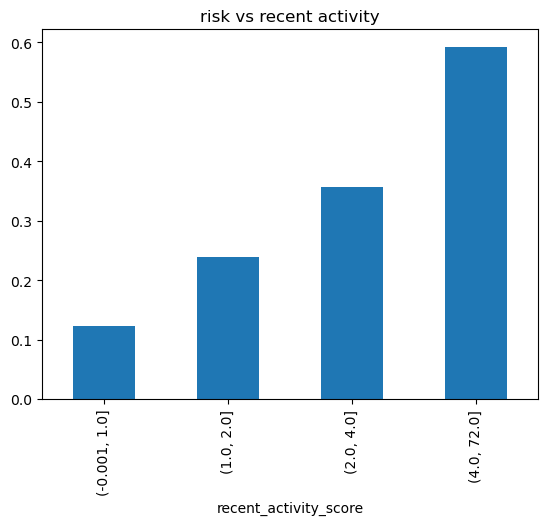

In [19]:
df1['recent_activity_score'] = df1['total_tl_opened_l6m'] + df1['enq_l6m']

activity_risk = df1.groupby(pd.qcut(df1['recent_activity_score'], 5, duplicates='drop'))['approved_flag'].mean()

activity_risk.plot(kind='bar', title="risk vs recent activity")
plt.show()


In [20]:
## Variable which highly correlated with approved_flag

corr = df1.corr(numeric_only=True)['approved_flag'].abs().sort_values(ascending=False)
corr[1:11]

credit_score              0.643964
enq_l3m                   0.461950
enq_l6m                   0.422049
pct_pl_enq_l6m_of_ever    0.384625
recent_activity_score     0.382085
pct_pl_enq_l6m_of_l12m    0.378286
enq_l12m                  0.370907
pl_enq_l6m                0.321441
pl_enq_l12m               0.283283
tot_enq                   0.252794
Name: approved_flag, dtype: float64

In [21]:
## creating the new varibel in df1 called stress_risk

df1['stress_score'] = (df1['tot_missed_pmnt'] +df1['num_times_delinquent'] +df1['enq_l3m'])

## Percentage of riksy customer in group of stress_score

stress_risk = df1.groupby(pd.qcut(df1['stress_score'],5,duplicates='drop'))[['approved_flag']].mean()

stress_risk

,approved_flag
stress_score,
"(-0.001, 1.0]",0.081876
"(1.0, 2.0]",0.259360
"(2.0, 5.0]",0.454305
"(5.0, 78.0]",0.505208


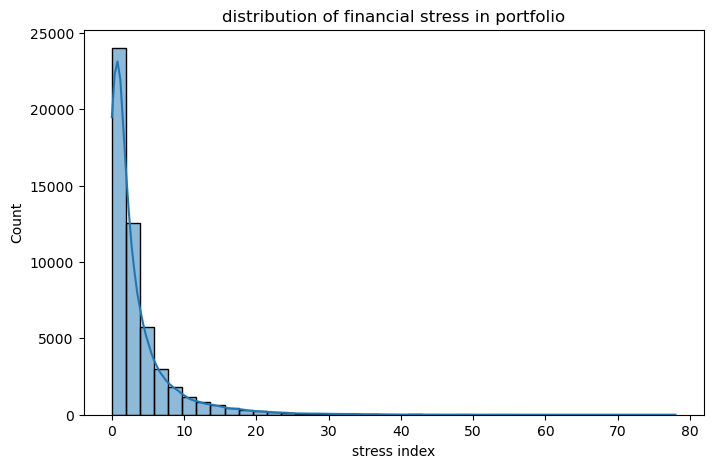

In [22]:
## Creating a new column called  stress index
df1['stress_index'] = ( df1['num_times_delinquent']+ df1['tot_missed_pmnt']+ df1['enq_l3m'])

## ploting the stress_index in histogram

plt.figure(figsize=(8,5))
sns.histplot(df1['stress_index'], bins=40, kde=True)
plt.title("distribution of financial stress in portfolio")
plt.xlabel("stress index")
plt.show()


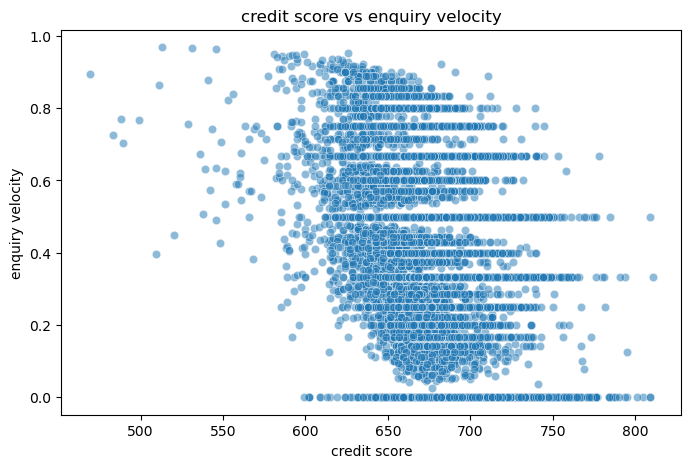

In [23]:
df1['enquiry_velocity'] = df1['enq_l3m'] / (df1['enq_l12m'] + 1)

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df1,
    x='credit_score',
    y='enquiry_velocity',
    alpha=0.5
)

plt.title("credit score vs enquiry velocity")
plt.xlabel("credit score")
plt.ylabel("enquiry velocity")
plt.show()

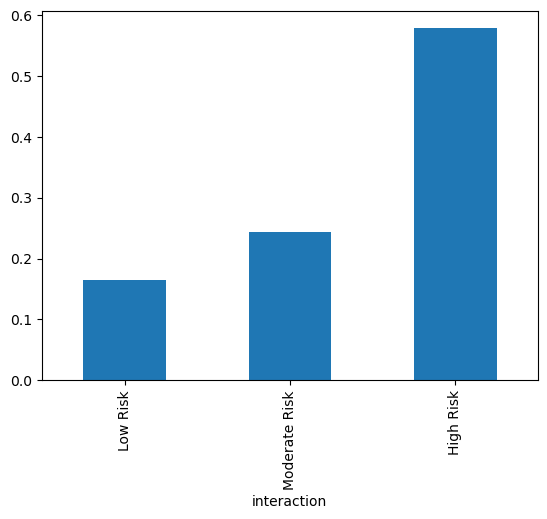

In [24]:
# When two risky behaviors come together, the total risk becomes much higher than each one individually

# Creating the new col in interaction
df1['interaction'] = df1['enq_l3m'] * df1['pct_currentbal_all_tl']

## Creating a bar graph 

interaction_risk = df.groupby(pd.qcut(df1['interaction'],5,duplicates='drop',labels = ['Low Risk','Moderate Risk','High Risk']))['approved_flag'].mean()
interaction_risk.plot(kind='bar')
plt.show()


In [25]:
## If we apply this rule to aprrove the loan  how risky will the approved customers be

policy = df1[(df1['credit_score'] > 700) &(df1['enq_l3m'] < 2) &(df1['pct_currentbal_all_tl'] < 60)]

## Risk Percentage bank will get if the follow this ploicy 

policy_risk = policy['approved_flag'].mean()
policy_risk

np.float64(0.1075031525851198)

# Hypothesis Testing

### (1) Testing The Relationship Between Gender Features And Approval Flag
- NUll hypo = Gender and Risk are independent 
- ALT hypo = Gender Impacts Risk
- significance level = 0.05 
- P-Value =  0.115
### Conclusion
    - SO the p-value > significance level
    - I conclude gender Doesn't Impact Risk
    


In [26]:
contingency = pd.crosstab(df1['gender'], df1['approved_flag'])

chi2, p_value, dof, expected = chi2_contingency(contingency)

print("p-value:", p_value)

p-value: 0.11544574066300985


### (2) Does High Credit Utilization Increase Default Risk

- NUll hypo = Mean utilization is same for risky & safe customers
- ALT hypo = Risky customers have higher utilization
- significance level = 0.05 
- P-Value =  8.7e-10
### Conclusion
    - SO the p-value < significance level
    - I conclude Risky customers have higher utilization
    


In [27]:
risk = df[df['approved_flag']==1]['pct_currentbal_all_tl']
safe = df[df['approved_flag']==0]['pct_currentbal_all_tl']

t_value,p_value = ttest_ind(risk, safe, equal_var=False)
print(p_value)

8.799220726808485e-10


### (3) Does Past Delinquency Strongly Predict Risk

- NUll hypo = Delinquency is not related to risk
- ALT hypo = Higher The Delinquency higher the Risk
- significance level = 0.05 
- P-Value =  0.0
### Conclusion
    - SO the p-value < significance level
    - I conclude Delinquency Increases risk also increases 
    


In [28]:
# Create delinquency group

df1['delinq_group'] = df1['num_times_delinquent'].apply( lambda x: 'delinq' if x > 0 else 'no_delinq')

# Contingency table
cont_table = pd.crosstab(df1['delinq_group'], df1['approved_flag'])

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(cont_table)

print("p-value:", p_value)

p-value: 0.0


### (4) Does Credit Score Effectively Distinguish Risky vs Safe Customers

- NUll hypo = Mean score is same for risky and safe customers
- ALT hypo = Mean score is different
- significance level = 0.05 
- P-Value =  0.0
### Conclusion
    - SO the p-value < significance level
    - I conclude Mean score is different

In [29]:

risk = df1[df1['approved_flag'] == 1]['credit_score']
safe = df1[df1['approved_flag'] == 0]['credit_score']

t_stat, p_value = ttest_ind(risk, safe, equal_var=False)

print("p-value:", p_value)

p-value: 0.0


# Pre Modelling Stage

In [30]:
# Dropping the Id Variable

del df['prospectid']

### Checking for the outliers in numeric columns

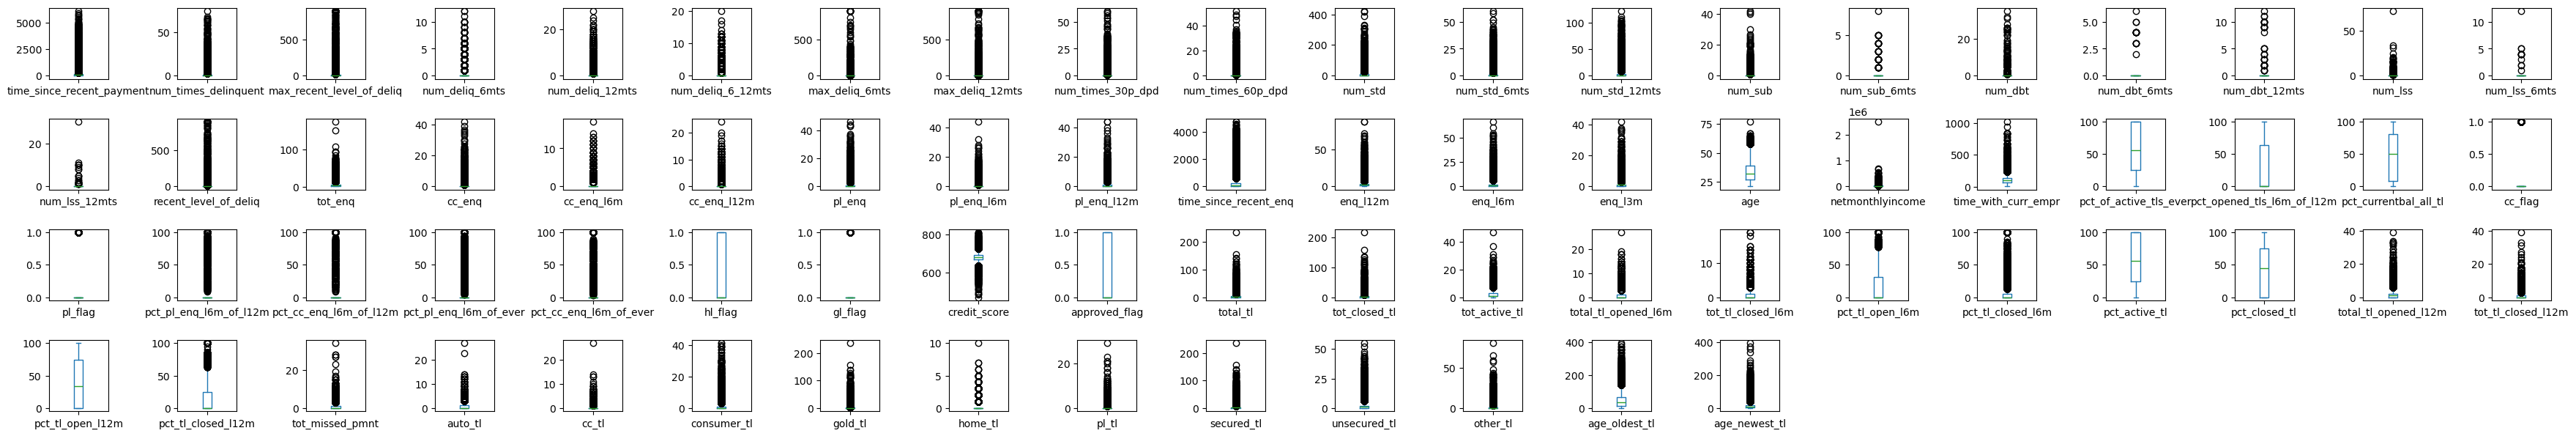

In [31]:
df.select_dtypes(exclude='object').plot(kind='box', subplots=True, layout=(20,20), figsize=(35,30))
plt.tight_layout()
plt.show()

## Splitting The Data

In [32]:
# splitting the data to numerical and categorical variables
## some variables  are in numeric data type but they are not numeric 

# numerical variables
num_var = df[df.select_dtypes(exclude='object').columns.difference(['cc_flag','pl_flag','hl_flag' ,'gl_flag','approved_flag'])]

non_out_perf_var= num_var[['num_deliq_6mts','num_deliq_12mts','num_deliq_6_12mts','num_times_60p_dpd','num_times_30p_dpd','num_std_6mts',
                          'num_sub','num_sub_6mts','num_dbt','num_dbt_6mts','num_dbt_12mts','num_lss','num_lss_6mts','num_lss_12mts','cc_enq',
                          'cc_enq_l6m','cc_enq_l12m','pl_enq','pl_enq_l6m','pl_enq_l12m','enq_l12m','enq_l6m','enq_l3m','pct_pl_enq_l6m_of_l12m',
                          'pct_cc_enq_l6m_of_l12m','pct_pl_enq_l6m_of_ever','pct_cc_enq_l6m_of_ever','total_tl_opened_l6m','pct_tl_open_l6m',
                          'pct_tl_closed_l6m','pct_active_tl','pct_closed_tl','tot_tl_closed_l12m','tot_missed_pmnt','auto_tl','cc_tl',
                          'consumer_tl','home_tl','pl_tl']]

out_perf_num_var = num_var[num_var.columns.difference(non_out_perf_var.columns)]

# categorical variables
cat_var = df[df.select_dtypes(include='object').columns.to_list() + ['cc_flag','pl_flag','hl_flag' ,'gl_flag']]

odinal_cat_var = cat_var['education']

nominal_cat_var = cat_var[['first_prod_enq2','gender','last_prod_enq2','maritalstatus']]

non_enc_cat_var = cat_var[['cc_flag','pl_flag','hl_flag','gl_flag']]



# Y variables
y_var = df['approved_flag']

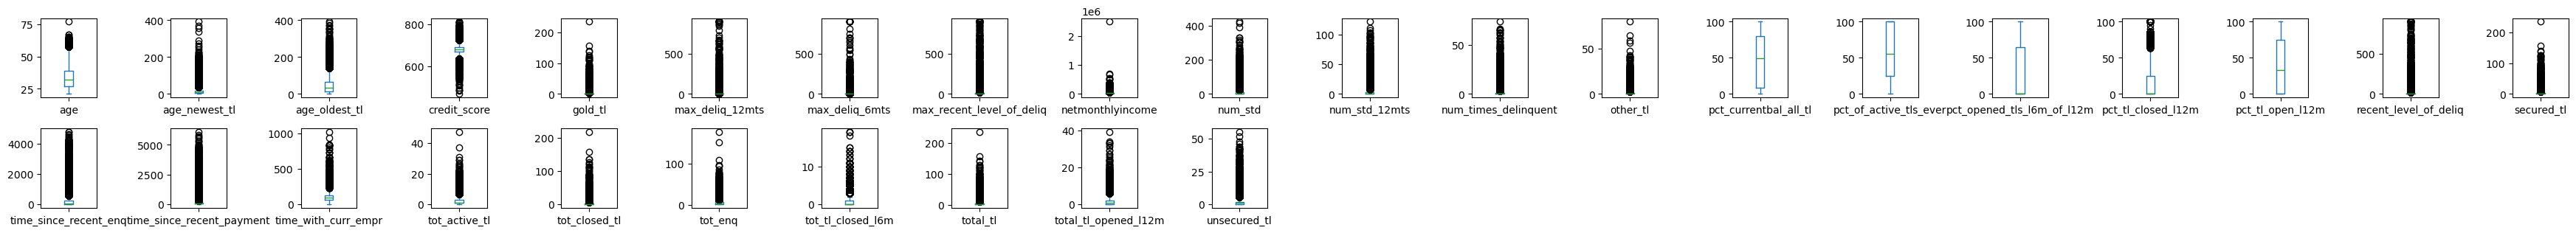

In [33]:
out_perf_num_var.select_dtypes(exclude='object').plot(kind='box', subplots=True, layout=(20,20), figsize=(35,30))
plt.tight_layout()
plt.show()

## Outlier Treatment For NUmeric Variable 

In [34]:
for col in out_perf_num_var:
    lower_bound = out_perf_num_var[col].quantile(0.01)
    upper_bound = out_perf_num_var[col].quantile(0.99)
    out_perf_num_var[col] = num_var[col].clip(lower=lower_bound, upper=upper_bound)

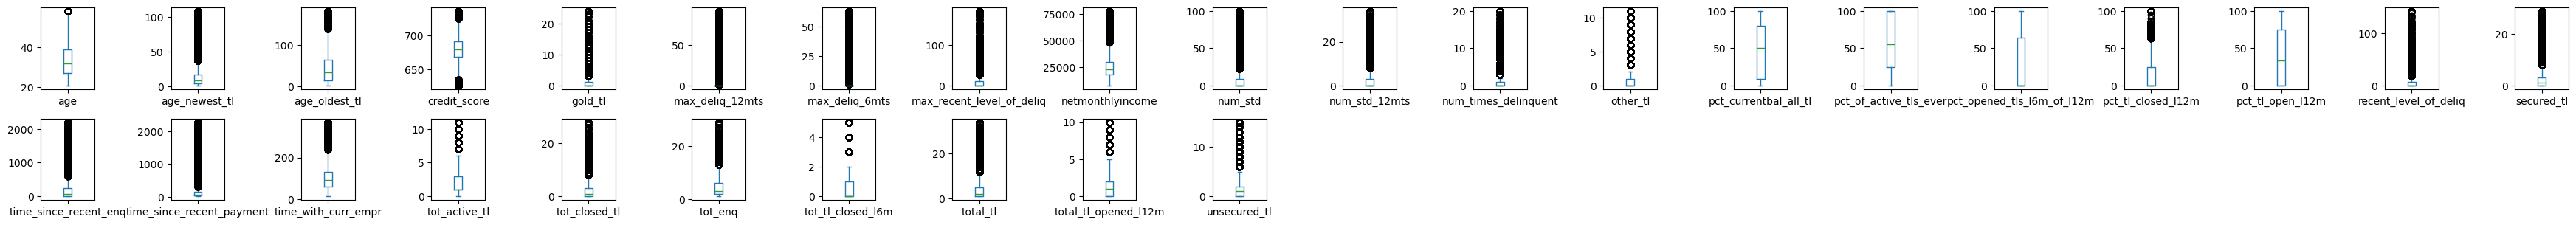

In [35]:
### result after the outliers treatment 

out_perf_num_var.plot(kind='box', subplots=True, layout=(20,20), figsize=(35,30))
plt.tight_layout()
plt.show()

In [36]:
### Combing the both non_out_perf_var,out_perf_num_var as clean_num_var 

clean_num_var = pd.concat([non_out_perf_var,out_perf_num_var],axis = 1)

## Encoding

In [37]:
## label encoding 

##  Converting the 'OTHERS' category is to mode of the column 
odinal_cat_var = pd.Series(np.where(odinal_cat_var == 'OTHERS',odinal_cat_var.mode([0]),odinal_cat_var),name='education')

education_mapping = {
    'SSC': 0,
    '12TH': 1,
    'UNDER GRADUATE': 2,
    'GRADUATE': 3,
    'POST-GRADUATE': 4,
    'PROFESSIONAL': 5  
}

odinal_cat_var = odinal_cat_var.map(education_mapping)

In [38]:
## One hot encoding 

nominal_cat_var = pd.get_dummies(nominal_cat_var,drop_first=True).astype('int')


In [39]:
# ### Combing the nominal_cat_var,odinal_cat_var,non_enc_cat_var as clean_cat_var


clean_cat_var = pd.concat([nominal_cat_var,odinal_cat_var,non_enc_cat_var],axis=1)

## Combining The Data set Back`

In [40]:
clean_df = pd.concat([clean_num_var,clean_cat_var],axis=1)

# Feature Selection

## correlation 

<Axes: >

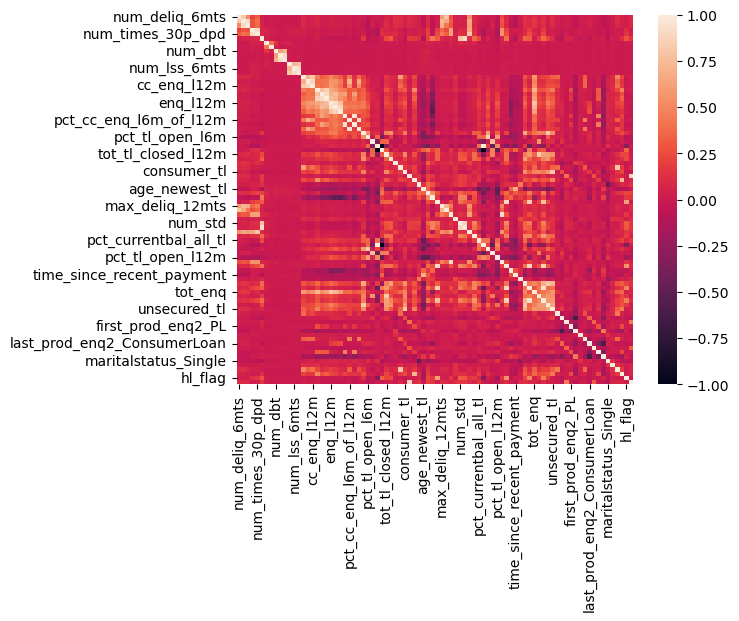

In [41]:
sns.heatmap(clean_df.corr())

In [42]:
(clean_df.corrwith(y_var)*100).sort_values(ascending = False).head(10)

enq_l3m                   46.195048
enq_l6m                   42.204922
pct_pl_enq_l6m_of_ever    38.462509
pct_pl_enq_l6m_of_l12m    37.828591
enq_l12m                  37.090741
pl_enq_l6m                32.144139
pl_enq_l12m               28.328336
tot_enq                   27.175192
pl_enq                    20.994084
pct_tl_open_l6m           20.760378
dtype: float64

In [43]:
(clean_df.corrwith(y_var)*100).sort_values(ascending = False).tail(10)

first_prod_enq2_others   -10.415116
age_newest_tl            -10.708822
age                      -13.932276
num_std_6mts             -16.392192
num_std                  -18.040309
num_std_12mts            -18.634696
last_prod_enq2_others    -21.166391
age_oldest_tl            -21.686367
time_since_recent_enq    -21.777901
credit_score             -66.409802
dtype: float64

## KBest

In [44]:
from sklearn.feature_selection import SelectKBest,f_classif

In [45]:
x=clean_df
y=y_var

selector=SelectKBest(score_func=f_classif,k='all')
selector.fit(x,y)

f_scores =  pd.DataFrame({
'Variable': x.columns,
'F_score': selector.scores_,
'p_value': selector.pvalues_
}) 

f_scores = (f_scores.sort_values(by='F_score', ascending=False))

kbest_imp_var = f_scores.head(20)['Variable'].tolist()

## Anova

In [46]:
from sklearn.feature_selection import f_classif

X = clean_df
y = y_var

f_values, p_values = f_classif(X, y)

anova_df = pd.DataFrame({
    'Feature': X.columns,
    'p_value': p_values,
    'F_value': f_values
}).sort_values(by='F_value', ascending=False)

anova_imp_var = anova_df.head(25)['Feature'].to_list()
anova_imp_var

['credit_score',
 'enq_l3m',
 'enq_l6m',
 'pct_pl_enq_l6m_of_ever',
 'pct_pl_enq_l6m_of_l12m',
 'enq_l12m',
 'pl_enq_l6m',
 'pl_enq_l12m',
 'tot_enq',
 'time_since_recent_enq',
 'age_oldest_tl',
 'last_prod_enq2_others',
 'pl_enq',
 'pct_tl_open_l6m',
 'last_prod_enq2_ConsumerLoan',
 'num_std_12mts',
 'num_std',
 'cc_enq_l6m',
 'pct_tl_open_l12m',
 'pct_cc_enq_l6m_of_l12m',
 'pct_cc_enq_l6m_of_ever',
 'cc_enq_l12m',
 'num_std_6mts',
 'recent_level_of_deliq',
 'pct_opened_tls_l6m_of_l12m']

# RFE

In [47]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

In [48]:
model = LogisticRegression(max_iter=200)

rfe = RFE(model, n_features_to_select=20)
rfe.fit(X,y)

important_rfe = X.columns[rfe.support_]
important_rfe=important_rfe.to_list()

In [49]:
## selecting the unique feature from the 3 feature reduction methods

imp_var= pd.concat([pd.Series(kbest_imp_var),pd.Series(important_rfe),pd.Series(anova_imp_var)]).unique()

## VIF

In [50]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# features = clean_df[imp_var]

# vif_df = pd.DataFrame()
# vif_df["Feature"] = features.columns
# vif_df["VIF"] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]

# vif_df = vif_df.sort_values(by="VIF", ascending=False)
# vif_df

In [51]:

X = clean_df[imp_var].copy()

while True:
    X_const = add_constant(X)
    
    vif = pd.DataFrame()
    vif["Feature"] = X_const.columns
    vif["VIF"] = [variance_inflation_factor(X_const.values, i) 
                  for i in range(X_const.shape[1])]
    
    vif = vif[vif["Feature"] != "const"]
    
    max_vif = vif["VIF"].max()
    
    if max_vif > 5:
        drop_feature = vif.sort_values("VIF", ascending=False)["Feature"].iloc[0]
        print(f"Removing: {drop_feature} (VIF={max_vif})")
        X = X.drop(columns=[drop_feature])
    else:
        break

print("Final Features:", X.columns)

Removing: pct_closed_tl (VIF=inf)
Removing: pct_of_active_tls_ever (VIF=inf)
Removing: enq_l6m (VIF=20.98307040618706)
Removing: pct_pl_enq_l6m_of_l12m (VIF=20.212849127138192)
Removing: pct_cc_enq_l6m_of_l12m (VIF=16.915242210473412)
Removing: pl_enq_l12m (VIF=13.23456803361111)
Removing: num_std_12mts (VIF=12.087593476056357)
Removing: num_times_30p_dpd (VIF=10.900139537581026)
Removing: enq_l12m (VIF=7.796177813820388)
Removing: cc_enq_l6m (VIF=7.327853757768103)
Removing: pct_tl_open_l6m (VIF=5.038610942931797)
Final Features: Index(['credit_score', 'enq_l3m', 'pct_pl_enq_l6m_of_ever', 'pl_enq_l6m',
       'tot_enq', 'time_since_recent_enq', 'age_oldest_tl',
       'last_prod_enq2_others', 'pl_enq', 'last_prod_enq2_ConsumerLoan',
       'num_std', 'pct_tl_open_l12m', 'num_times_60p_dpd', 'num_sub',
       'pct_active_tl', 'auto_tl', 'cc_tl', 'home_tl', 'num_times_delinquent',
       'first_prod_enq2_PL', 'first_prod_enq2_others', 'gender_M',
       'last_prod_enq2_PL', 'gl_flag', '

In [52]:
final_df = clean_df[X.columns]
final_df['approved_flag'] = y_var
final_df

,credit_score,enq_l3m,pct_pl_enq_l6m_of_ever,pl_enq_l6m,tot_enq,time_since_recent_enq,age_oldest_tl,last_prod_enq2_others,pl_enq,last_prod_enq2_ConsumerLoan,...,first_prod_enq2_others,gender_M,last_prod_enq2_PL,gl_flag,pct_cc_enq_l6m_of_ever,cc_enq_l12m,num_std_6mts,recent_level_of_deliq,pct_opened_tls_l6m_of_l12m,approved_flag
0,689.0,1,0.0,0,3,75.0,43,1,0,0,...,1,1,0,0,0.0,0,2,0,0.0,0
1,665.0,0,0.0,0,6,131.0,13,1,0,0,...,0,1,0,0,0.0,0,0,27,33.3,1
2,676.0,1,0.0,0,2,4.0,8,0,0,1,...,1,1,0,0,0.0,0,0,0,0.0,0
3,681.0,1,0.0,0,3,75.0,42,1,0,0,...,1,1,0,0,0.0,0,0,0,0.0,0
4,702.0,1,0.0,0,3,75.0,19,1,0,0,...,1,0,0,0,0.0,0,5,0,50.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51331,690.0,0,0.0,0,2,266.0,13,1,0,0,...,0,1,0,0,0.0,0,0,0,0.0,0
51332,682.0,0,0.0,0,1,98.0,3,0,0,1,...,0,0,0,0,0.0,0,0,0,100.0,0
51333,685.0,1,0.0,0,1,9.0,46,1,0,0,...,1,0,0,0,0.0,0,0,0,0.0,0
51334,647.0,5,100.0,1,20,6.0,15,0,1,0,...,0,1,0,0,0.0,0,0,0,80.0,1


## Splitting the data into train and test

In [53]:
from sklearn.model_selection import train_test_split

train,test = train_test_split(final_df,test_size = 0.30,random_state=000)
train.shape,test.shape

((35935, 30), (15401, 30))

## Modeling 

In [54]:
import statsmodels.formula.api as smf 

In [55]:
col = train.columns 
col = col.str.replace('approved_flag','')

equ = "approved_flag~" + "+".join([c for c in col if c.strip()])
equ

'approved_flag~credit_score+enq_l3m+pct_pl_enq_l6m_of_ever+pl_enq_l6m+tot_enq+time_since_recent_enq+age_oldest_tl+last_prod_enq2_others+pl_enq+last_prod_enq2_ConsumerLoan+num_std+pct_tl_open_l12m+num_times_60p_dpd+num_sub+pct_active_tl+auto_tl+cc_tl+home_tl+num_times_delinquent+first_prod_enq2_PL+first_prod_enq2_others+gender_M+last_prod_enq2_PL+gl_flag+pct_cc_enq_l6m_of_ever+cc_enq_l12m+num_std_6mts+recent_level_of_deliq+pct_opened_tls_l6m_of_l12m'

In [56]:
import statsmodels.formula.api as smf 
model = smf.logit(equ,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                    Logit                Method:               MLE       
Dependent Variable:       approved_flag        Pseudo R-squared:     0.642     
Date:                     2026-05-12 11:48     AIC:                  14758.8903
No. Observations:         35935                BIC:                  15013.5743
Df Model:                 29                   Log-Likelihood:       -7349.4   
Df Residuals:             35905                LL-Null:              -20550.   
Converged:                1.0000               LLR p-value:          0.0000    
No. Iterations:           9.0000               Scale:                1.0000    
-------------------------------------------------------------------------------
                             Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
-------------------------------------------------------------------------------
Intercept                   177.9734   2.6400  67.4142 0.0000 172.7991 18

In [57]:
## iteration 2

equ2 = equ.replace('+cc_tl','')

model = smf.logit(equ2,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                    Logit                Method:               MLE       
Dependent Variable:       approved_flag        Pseudo R-squared:     0.642     
Date:                     2026-05-12 11:48     AIC:                  14756.9012
No. Observations:         35935                BIC:                  15003.0958
Df Model:                 28                   Log-Likelihood:       -7349.5   
Df Residuals:             35906                LL-Null:              -20550.   
Converged:                1.0000               LLR p-value:          0.0000    
No. Iterations:           9.0000               Scale:                1.0000    
-------------------------------------------------------------------------------
                             Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
-------------------------------------------------------------------------------
Intercept                   177.9725   2.6400  67.4144 0.0000 172.7983 18

In [58]:
## iteration 3

equ3 = equ2.replace('+pl_enq_l6m','')

model = smf.logit(equ3,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                    Logit                Method:               MLE       
Dependent Variable:       approved_flag        Pseudo R-squared:     0.642     
Date:                     2026-05-12 11:48     AIC:                  14754.9319
No. Observations:         35935                BIC:                  14992.6370
Df Model:                 27                   Log-Likelihood:       -7349.5   
Df Residuals:             35907                LL-Null:              -20550.   
Converged:                1.0000               LLR p-value:          0.0000    
No. Iterations:           9.0000               Scale:                1.0000    
-------------------------------------------------------------------------------
                             Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
-------------------------------------------------------------------------------
Intercept                   177.9827   2.6394  67.4338 0.0000 172.8097 18

In [59]:
 
## iteration 4

equ4 = equ3.replace('+pct_active_tl','')

model = smf.logit(equ4,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                    Logit                Method:               MLE       
Dependent Variable:       approved_flag        Pseudo R-squared:     0.642     
Date:                     2026-05-12 11:48     AIC:                  14753.0575
No. Observations:         35935                BIC:                  14982.2731
Df Model:                 26                   Log-Likelihood:       -7349.5   
Df Residuals:             35908                LL-Null:              -20550.   
Converged:                1.0000               LLR p-value:          0.0000    
No. Iterations:           9.0000               Scale:                1.0000    
-------------------------------------------------------------------------------
                             Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
-------------------------------------------------------------------------------
Intercept                   177.9633   2.6387  67.4434 0.0000 172.7916 18

In [60]:

 
## iteration 5

equ5 = equ4.replace('+last_prod_enq2_ConsumerLoan','')

model = smf.logit(equ5,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                   Logit                Method:               MLE       
Dependent Variable:      approved_flag        Pseudo R-squared:     0.642     
Date:                    2026-05-12 11:48     AIC:                  14751.2858
No. Observations:        35935                BIC:                  14972.0119
Df Model:                25                   Log-Likelihood:       -7349.6   
Df Residuals:            35909                LL-Null:              -20550.   
Converged:               1.0000               LLR p-value:          0.0000    
No. Iterations:          9.0000               Scale:                1.0000    
------------------------------------------------------------------------------
                            Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
------------------------------------------------------------------------------
Intercept                  178.0136   2.6369  67.5087 0.0000 172.8454 183.1818
credi

In [61]:
 
## iteration 6

equ6 = equ5.replace('+pct_cc_enq_l6m_of_ever','')

model = smf.logit(equ6,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                   Logit                Method:               MLE       
Dependent Variable:      approved_flag        Pseudo R-squared:     0.642     
Date:                    2026-05-12 11:48     AIC:                  14749.5864
No. Observations:        35935                BIC:                  14961.8230
Df Model:                24                   Log-Likelihood:       -7349.8   
Df Residuals:            35910                LL-Null:              -20550.   
Converged:               1.0000               LLR p-value:          0.0000    
No. Iterations:          9.0000               Scale:                1.0000    
------------------------------------------------------------------------------
                            Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
------------------------------------------------------------------------------
Intercept                  177.9970   2.6366  67.5104 0.0000 172.8294 183.1646
credi

In [62]:
# cc_enq_l12m
 
## iteration 7

equ7 = equ6.replace('+cc_enq_l12m','')

model = smf.logit(equ7,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                   Logit                Method:               MLE       
Dependent Variable:      approved_flag        Pseudo R-squared:     0.642     
Date:                    2026-05-12 11:48     AIC:                  14747.7473
No. Observations:        35935                BIC:                  14951.4945
Df Model:                23                   Log-Likelihood:       -7349.9   
Df Residuals:            35911                LL-Null:              -20550.   
Converged:               1.0000               LLR p-value:          0.0000    
No. Iterations:          9.0000               Scale:                1.0000    
------------------------------------------------------------------------------
                            Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
------------------------------------------------------------------------------
Intercept                  177.9992   2.6365  67.5123 0.0000 172.8316 183.1667
credi

In [63]:
 
## iteration 8

equ8 = equ7.replace('+num_sub','')

model = smf.logit(equ8,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                   Logit                Method:               MLE       
Dependent Variable:      approved_flag        Pseudo R-squared:     0.642     
Date:                    2026-05-12 11:48     AIC:                  14746.2193
No. Observations:        35935                BIC:                  14941.4771
Df Model:                22                   Log-Likelihood:       -7350.1   
Df Residuals:            35912                LL-Null:              -20550.   
Converged:               1.0000               LLR p-value:          0.0000    
No. Iterations:          9.0000               Scale:                1.0000    
------------------------------------------------------------------------------
                            Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
------------------------------------------------------------------------------
Intercept                  178.0130   2.6365  67.5180 0.0000 172.8455 183.1805
credi

In [64]:
 
## iteration 9

equ9 = equ8.replace('+home_tl','')

model = smf.logit(equ9,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                   Logit                Method:               MLE       
Dependent Variable:      approved_flag        Pseudo R-squared:     0.642     
Date:                    2026-05-12 11:48     AIC:                  14744.7696
No. Observations:        35935                BIC:                  14931.5379
Df Model:                21                   Log-Likelihood:       -7350.4   
Df Residuals:            35913                LL-Null:              -20550.   
Converged:               1.0000               LLR p-value:          0.0000    
No. Iterations:          9.0000               Scale:                1.0000    
------------------------------------------------------------------------------
                            Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
------------------------------------------------------------------------------
Intercept                  177.9845   2.6360  67.5199 0.0000 172.8180 183.1511
credi

In [65]:
 
## iteration 10

equ10 = equ9.replace('+gl_flag','')

model = smf.logit(equ10,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                   Logit                Method:               MLE       
Dependent Variable:      approved_flag        Pseudo R-squared:     0.642     
Date:                    2026-05-12 11:48     AIC:                  14743.0483
No. Observations:        35935                BIC:                  14921.3271
Df Model:                20                   Log-Likelihood:       -7350.5   
Df Residuals:            35914                LL-Null:              -20550.   
Converged:               1.0000               LLR p-value:          0.0000    
No. Iterations:          9.0000               Scale:                1.0000    
------------------------------------------------------------------------------
                            Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
------------------------------------------------------------------------------
Intercept                  178.0076   2.6359  67.5329 0.0000 172.8414 183.1738
credi

In [66]:
 
## iteration 11

equ11 = equ10.replace('+first_prod_enq2_others','')

model = smf.logit(equ11,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                   Logit                Method:               MLE       
Dependent Variable:      approved_flag        Pseudo R-squared:     0.642     
Date:                    2026-05-12 11:48     AIC:                  14741.7588
No. Observations:        35935                BIC:                  14911.5482
Df Model:                19                   Log-Likelihood:       -7350.9   
Df Residuals:            35915                LL-Null:              -20550.   
Converged:               1.0000               LLR p-value:          0.0000    
No. Iterations:          9.0000               Scale:                1.0000    
------------------------------------------------------------------------------
                            Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
------------------------------------------------------------------------------
Intercept                  177.9986   2.6357  67.5330 0.0000 172.8327 183.1645
credi

In [67]:
## iteration 12

equ12 = equ11.replace('+tot_enq','')

model = smf.logit(equ12,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                   Logit                Method:               MLE       
Dependent Variable:      approved_flag        Pseudo R-squared:     0.642     
Date:                    2026-05-12 11:48     AIC:                  14740.4699
No. Observations:        35935                BIC:                  14901.7698
Df Model:                18                   Log-Likelihood:       -7351.2   
Df Residuals:            35916                LL-Null:              -20550.   
Converged:               1.0000               LLR p-value:          0.0000    
No. Iterations:          9.0000               Scale:                1.0000    
------------------------------------------------------------------------------
                            Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
------------------------------------------------------------------------------
Intercept                  178.0560   2.6352  67.5683 0.0000 172.8911 183.2209
credi

In [68]:
## iteration 13

equ13 = equ12.replace('+num_times_delinquent','')

model = smf.logit(equ13,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                   Logit                Method:               MLE       
Dependent Variable:      approved_flag        Pseudo R-squared:     0.642     
Date:                    2026-05-12 11:48     AIC:                  14739.1941
No. Observations:        35935                BIC:                  14892.0045
Df Model:                17                   Log-Likelihood:       -7351.6   
Df Residuals:            35917                LL-Null:              -20550.   
Converged:               1.0000               LLR p-value:          0.0000    
No. Iterations:          9.0000               Scale:                1.0000    
------------------------------------------------------------------------------
                            Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
------------------------------------------------------------------------------
Intercept                  178.2896   2.6219  67.9998 0.0000 173.1507 183.4284
credi

In [69]:
## iteration 14

equ14 = equ13.replace('+num_times_60p_dpd','')

model = smf.logit(equ14,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                   Logit                Method:               MLE       
Dependent Variable:      approved_flag        Pseudo R-squared:     0.642     
Date:                    2026-05-12 11:48     AIC:                  14738.6140
No. Observations:        35935                BIC:                  14882.9350
Df Model:                16                   Log-Likelihood:       -7352.3   
Df Residuals:            35918                LL-Null:              -20550.   
Converged:               1.0000               LLR p-value:          0.0000    
No. Iterations:          9.0000               Scale:                1.0000    
------------------------------------------------------------------------------
                            Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
------------------------------------------------------------------------------
Intercept                  178.2437   2.6214  67.9957 0.0000 173.1058 183.3815
credi

In [70]:
## iteration 15

equ15 = equ14.replace('+auto_tl','')

model = smf.logit(equ15,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                   Logit                Method:               MLE       
Dependent Variable:      approved_flag        Pseudo R-squared:     0.642     
Date:                    2026-05-12 11:48     AIC:                  14738.5063
No. Observations:        35935                BIC:                  14874.3378
Df Model:                15                   Log-Likelihood:       -7353.3   
Df Residuals:            35919                LL-Null:              -20550.   
Converged:               1.0000               LLR p-value:          0.0000    
No. Iterations:          9.0000               Scale:                1.0000    
------------------------------------------------------------------------------
                            Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
------------------------------------------------------------------------------
Intercept                  178.2673   2.6215  68.0017 0.0000 173.1292 183.4054
credi

In [71]:
## iteration 16

equ16 = equ15.replace('+last_prod_enq2_PL','')

model = smf.logit(equ16,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                   Logit                Method:               MLE       
Dependent Variable:      approved_flag        Pseudo R-squared:     0.642     
Date:                    2026-05-12 11:48     AIC:                  14738.5174
No. Observations:        35935                BIC:                  14865.8594
Df Model:                14                   Log-Likelihood:       -7354.3   
Df Residuals:            35920                LL-Null:              -20550.   
Converged:               1.0000               LLR p-value:          0.0000    
No. Iterations:          9.0000               Scale:                1.0000    
------------------------------------------------------------------------------
                            Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
------------------------------------------------------------------------------
Intercept                  178.2742   2.6216  68.0009 0.0000 173.1359 183.4126
credi

In [72]:
## iteration 17

equ17 = equ16.replace('+first_prod_enq2_PL','')

model = smf.logit(equ17,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                   Logit                Method:               MLE       
Dependent Variable:      approved_flag        Pseudo R-squared:     0.642     
Date:                    2026-05-12 11:48     AIC:                  14738.9323
No. Observations:        35935                BIC:                  14857.7849
Df Model:                13                   Log-Likelihood:       -7355.5   
Df Residuals:            35921                LL-Null:              -20550.   
Converged:               1.0000               LLR p-value:          0.0000    
No. Iterations:          9.0000               Scale:                1.0000    
------------------------------------------------------------------------------
                            Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
------------------------------------------------------------------------------
Intercept                  178.3478   2.6215  68.0324 0.0000 173.2097 183.4858
credi

In [73]:
## iteration 18

equ18 = equ17.replace('+gender_M','')

model = smf.logit(equ18,data=train).fit(disp=False)
print(model.summary2())

                                Results: Logit
Model:                   Logit                Method:               MLE       
Dependent Variable:      approved_flag        Pseudo R-squared:     0.642     
Date:                    2026-05-12 11:48     AIC:                  14739.8645
No. Observations:        35935                BIC:                  14850.2275
Df Model:                12                   Log-Likelihood:       -7356.9   
Df Residuals:            35922                LL-Null:              -20550.   
Converged:               1.0000               LLR p-value:          0.0000    
No. Iterations:          9.0000               Scale:                1.0000    
------------------------------------------------------------------------------
                            Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
------------------------------------------------------------------------------
Intercept                  178.2194   2.6197  68.0292 0.0000 173.0848 183.3540
credi

In [74]:
## iteration 19

equ19 = equ18.replace('+pct_opened_tls_l6m_of_l12m','')

model = smf.logit(equ19,data=train).fit(disp=False)
print(model.summary2())

                              Results: Logit
Model:                 Logit               Method:              MLE       
Dependent Variable:    approved_flag       Pseudo R-squared:    0.642     
Date:                  2026-05-12 11:48    AIC:                 14740.9260
No. Observations:      35935               BIC:                 14842.7996
Df Model:              11                  Log-Likelihood:      -7358.5   
Df Residuals:          35923               LL-Null:             -20550.   
Converged:             1.0000              LLR p-value:         0.0000    
No. Iterations:        9.0000              Scale:               1.0000    
--------------------------------------------------------------------------
                        Coef.   Std.Err.    z     P>|z|   [0.025   0.975] 
--------------------------------------------------------------------------
Intercept              178.1357   2.6187  68.0242 0.0000 173.0031 183.2683
credit_score            -0.2678   0.0039 -68.3949 0.000

In [75]:
train = train[['credit_score','enq_l3m','pct_pl_enq_l6m_of_ever','time_since_recent_enq','age_oldest_tl','last_prod_enq2_others',
'pl_enq','num_std','pct_tl_open_l12m','num_std_6mts','recent_level_of_deliq','approved_flag']]

test = test[['credit_score','enq_l3m','pct_pl_enq_l6m_of_ever','time_since_recent_enq','age_oldest_tl','last_prod_enq2_others',
'pl_enq','num_std','pct_tl_open_l12m','num_std_6mts','recent_level_of_deliq','approved_flag']]

In [76]:
train_pred = model.predict(train)
train_pred

18798    0.801988
42978    0.000485
49824    0.001716
34193    0.155283
30634    0.110334
           ...   
21243    0.017131
45891    0.204051
42613    0.964234
43567    0.005001
2732     0.367775
Length: 35935, dtype: float64

In [77]:
test_pred = model.predict(test)
test_pred

23980    0.000777
3485     0.002438
49508    0.159163
1613     0.000101
32771    0.256255
           ...   
13590    0.083515
29952    0.017485
15902    0.000007
39083    0.019801
27996    0.000635
Length: 15401, dtype: float64

## Accuracy 

In [78]:
from sklearn.metrics import roc_auc_score

## test 

roc_auc = roc_auc_score(test['approved_flag'], test_pred)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.960661680781909


In [79]:
## train 

roc_auc = roc_auc_score(train['approved_flag'], train_pred)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9606554352595372


### Finding the best threshold value

In [80]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(train['approved_flag'], train_pred)

ks_values = tpr - fpr
best_threshold = thresholds[np.argmax(ks_values)]

print("Best Threshold (KS):", best_threshold)

Best Threshold (KS): 0.3990437520576052


In [81]:
train_predictions =  pd.DataFrame([train['approved_flag'],train_pred]).T
train_predictions.columns = [['actual','prob']]
train_predictions['pred'] = (train_predictions['prob'] > 0.40).astype('int')

In [82]:
test_predictions =  pd.DataFrame([test['approved_flag'],test_pred]).T
test_predictions.columns = [['actual','prob']]
test_predictions['pred'] = (test_predictions['prob'] > 0.40).astype('int')
test_predictions

,actual,prob,pred
23980,0.0,0.000777,0
3485,0.0,0.002438,0
49508,0.0,0.159163,0
1613,0.0,0.000101,0
32771,0.0,0.256255,0
...,...,...,...
13590,0.0,0.083515,0
29952,0.0,0.017485,0
15902,0.0,0.000007,0
39083,0.0,0.019801,0


### confusion matrix

In [83]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test['approved_flag'], test_predictions['pred'])

TN,FP,FN,TP = cm.ravel()

Sensitivity = TP / (TP + FN)
precision = TP / (TP + FP)
accuracy = (TP + TN) / (TP + TN + FP + FN)
specificity = TN / (TN + FP)

print('confusion matrix for test data')
print('-------------------------------')
print(f"Accuracy     : {accuracy:.3f}")
print(f"Sensitivity  : {Sensitivity:.3f}")
print(f"Specificity  : {specificity:.3f}")
print(f"Precision    : {precision:.3f}")

confusion matrix for test data
-------------------------------
Accuracy     : 0.966
Sensitivity  : 0.949
Specificity  : 0.972
Precision    : 0.924


In [84]:
cm = confusion_matrix(train['approved_flag'], train_predictions['pred'])

TN,FP,FN,TP = cm.ravel()

Sensitivity = TP / (TP + FN)
precision = TP / (TP + FP)
accuracy = (TP + TN) / (TP + TN + FP + FN)
specificity = TN / (TN + FP)

print('confusion matrix for train data')
print('-------------------------------')

print(f"Accuracy     : {accuracy:.3f}")
print(f"Sensitivity  : {Sensitivity:.3f}")
print(f"Specificity  : {specificity:.3f}")
print(f"Precision    : {precision:.3f}")

confusion matrix for train data
-------------------------------
Accuracy     : 0.965
Sensitivity  : 0.947
Specificity  : 0.971
Precision    : 0.920


# Deployment 

In [85]:
# model.save('model.pickle')

# import statsmodels.api as sm

# model = sm.load("model.pickle")
